<a href="https://colab.research.google.com/github/blbl-blbl/study/blob/main/PyTorch/%D0%9A%D0%BB%D0%B0%D1%81%D1%81%D0%B8%D1%84%D0%B8%D0%BA%D0%B0%D1%86%D0%B8%D1%8F_%D0%BF%D0%BE%D1%80%D0%BE%D0%B4_%D0%BA%D0%BE%D1%88%D0%B5%D0%BA_%D0%B8_%D1%81%D0%BE%D0%B1%D0%B0%D0%BA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Классификация пород кошек и собак по фотографии

План проекта:

| Этап | Что сделаем | Что осваиваем |
| :--- | :--- | :--- |
| 1. Исследование данных | Посмотрим изображения, размеры и баланс классов | EDA изображений |
| 2. Подготовка | Зафиксируем train/validation/test, преобразование и загрузчики | Обработка RGB, resize, нормализация |
| 3. Базовая модель | Обучим небольшую CNN с нуля | Самостоятельная адаптация архитектуры |
| 4. Transfer learning | Используем предобученную ResNet18, сначала заморозим основные слои | Предобученные веса, замена классификатора |
| 5. Улучшение | Попробуем аугментации и дообучение части сети | Fine-tuning, выбор learning rate |
| 6. Анализ | Изучим confusion matrix, метрики по классам и ошибки | Обоснование следующего эксперимента |
| 7. Завершение | Финальная оценка, загрузка модели, предсказание для фотографии | Воспроизводимый проект для портфолио |


Основная метрика - **macro-F1**, дополнительные метрики: accuracy и top-3 accuracy

In [1]:
import os

# Должно быть установлено до первого использования CUDA
os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"

import random
import numpy as np
import torch

torch.backends.cudnn.benchmark = False
torch.backends.cudnn.deterministic = True
torch.use_deterministic_algorithms(True)

def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

# 1. Загрузка и осмотр данных

100%|██████████| 792M/792M [00:32<00:00, 24.4MB/s]
100%|██████████| 19.2M/19.2M [00:01<00:00, 11.5MB/s]


Количество изображений: 3680
Тип изображения: <class 'PIL.Image.Image'>
Размер (ширина, высота): (394, 500)
Цветной режим: RGB
Метка класса: 0


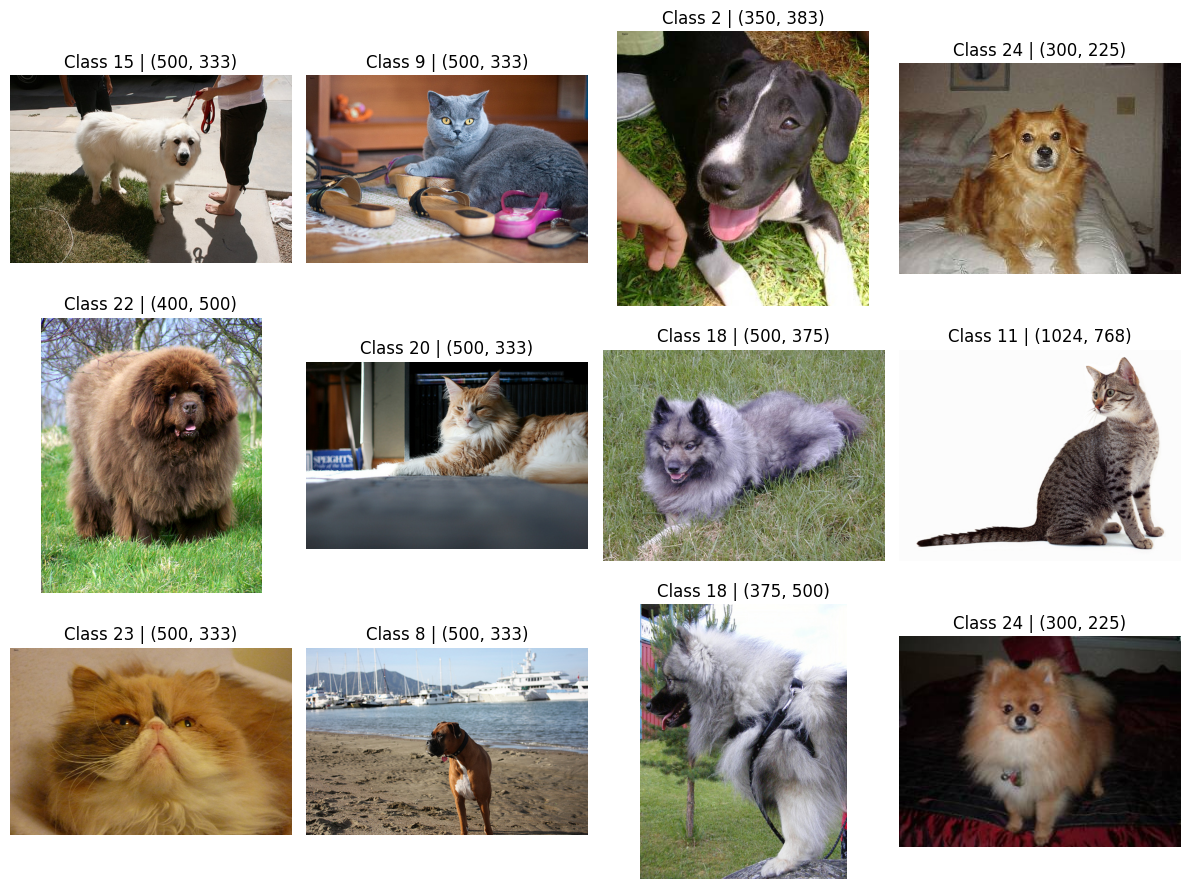

In [2]:
from torchvision.datasets import OxfordIIITPet
import matplotlib.pyplot as plt
import random

dataset = OxfordIIITPet(
    root="data",
    split="trainval",
    target_types="category",
    download=True,
)

print("Количество изображений:", len(dataset))

image, label = dataset[0]

print("Тип изображения:", type(image))
print("Размер (ширина, высота):", image.size)
print("Цветной режим:", image.mode)
print("Метка класса:", label)

indices = random.Random(42).sample(range(len(dataset)), 12)

fig, axes = plt.subplots(3, 4, figsize=(12, 9))

for ax, index in zip(axes.flat, indices):
  image, label = dataset[index]

  ax.imshow(image)
  ax.set_title(f"Class {label} | {image.size}")
  ax.axis("off")

plt.tight_layout()
plt.show()

In [3]:
import pandas as pd

rows = []

for index in range(len(dataset)):
  image, label = dataset[index]

  size = image.size
  rows.append({
      'index': index,
      'label': label,
      'width': size[0],
      'height': size[1],
      'aspect_ratio': size[0] / size[1]
  })

metadata = pd.DataFrame(rows)


print(metadata.head())

print(
    metadata[["width", "height", "aspect_ratio"]].describe()
)

class_counts = metadata["label"].value_counts().sort_index()

print("Количество классов:", len(class_counts))
print("Минимум изображений на класс:", class_counts.min())
print("Максимум изображений на класс:", class_counts.max())

   index  label  width  height  aspect_ratio
0      0      0    394     500      0.788000
1      1      0    450     313      1.437700
2      2      0    500     465      1.075269
3      3      0    500     351      1.424501
4      4      0    600     363      1.652893
             width       height  aspect_ratio
count  3680.000000  3680.000000   3680.000000
mean    431.033424   383.420380      1.176343
std     126.328303   116.833678      0.322537
min     114.000000   108.000000      0.516000
25%     333.000000   333.000000      0.782000
50%     500.000000   375.000000      1.333333
75%     500.000000   500.000000      1.461988
max    3264.000000  2606.000000      2.564103
Количество классов: 37
Минимум изображений на класс: 93
Максимум изображений на класс: 100


## Фиксация train и validation

Разделим 3680 изображений из `trainval` в пропорции 80/20. Используем стратификацию, чтобы сохранить примерно одинаковые доли пород в обеих частях:

In [4]:
from sklearn.model_selection import train_test_split

train_indices, val_indices = train_test_split(
    metadata["index"].to_numpy(),
    test_size=0.2,
    random_state=42,
    stratify=metadata["label"].to_numpy(),
)

print("Train:", len(train_indices))
print("Validation:", len(val_indices))
print("Пересечение:", len(set(train_indices) & set(val_indices)))

Train: 2944
Validation: 736
Пересечение: 0


## Выбор способа изменения размера

| Подход | Преимущество | Недостаток |
| :--- | :--- | :--- |
| Растянуть до квадрата | Простота | Искажаются пропорции |
| Масштабировать и обрезать | Сохраняются пропорции | Можно отрезать часть животного |
| Масштабировать и добавить поля | Сохраняются пропорции и весь кадр | Часть площади занимают поля |


Для первой CNN будем использовать **масштабирование с добавлением полей до `224×224`** это исходное решение, качество которого позже можно будет сравнить с другими вариантами

Например, фотография размером 400 × 200:
  1. Уменьшается до 224 × 112
  2. Получает по **56 пикселей поля сверху и снизу**
  3. Итоговый размер - 224 × 224

Важно: пропорции сохраняются, но мелкие детали при уменьшении могут потеряться


### Преобразование размера:


In [5]:
from torchvision import transforms
from torchvision.transforms import functional as TF


class ResizeWithPadding:
    def __init__(self, size=224):
        self.size = size

    def __call__(self, image):
        image = image.convert("RGB")
        width, height = image.size

        scale = self.size / max(width, height)

        new_width = max(1, round(width * scale))
        new_height = max(1, round(height * scale))

        image = TF.resize(
            image,
            [new_height, new_width],
            antialias=True,
        )

        # Берём фактические размеры после resize
        width, height = image.size

        left = (self.size - width) // 2
        right = self.size - width - left

        top = (self.size - height) // 2
        bottom = self.size - height - top

        return TF.pad(
            image,
            [left, top, right, bottom],
            fill=0,
        )

`__call__` позволяет использовать экземляр класса как функцию:

```
resize = ResizeWithPadding(224)
resized_image = resize(image)
```

Проверка


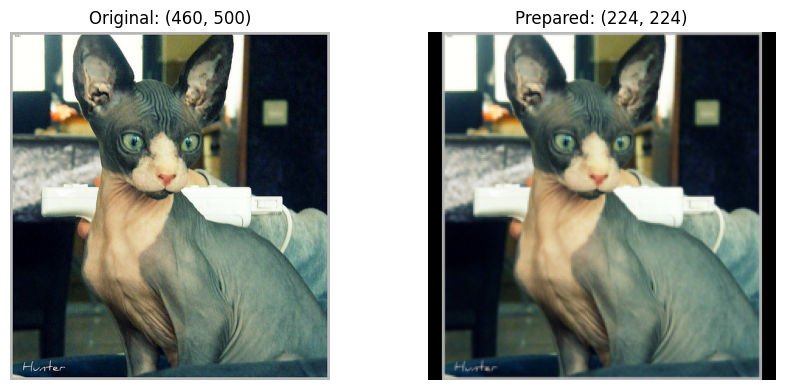

In [6]:
image, label = dataset[int(train_indices[0])]

resize = ResizeWithPadding(224)
prepared_image = resize(image)

fig, axes = plt.subplots(1, 2, figsize=(9, 4))

axes[0].imshow(image)
axes[0].set_title(f"Original: {image.size}")

axes[1].imshow(prepared_image)
axes[1].set_title(f"Prepared: {prepared_image.size}")

for ax in axes:
  ax.axis("off")

plt.tight_layout()
plt.show()

Добавление преобразования в тензор:

In [7]:
basic_transform = transforms.Compose([
    ResizeWithPadding(224),
    transforms.ToTensor(),
])

image_tensor = basic_transform(image)

print("Shape:", image_tensor.shape)
print("Dtype:", image_tensor.dtype)
print("Range:", image_tensor.min().item(), image_tensor.max().item())

Shape: torch.Size([3, 224, 224])
Dtype: torch.float32
Range: 0.0 1.0


### Создаем обучающую и валидационную части

In [8]:
from torch.utils.data import Subset, DataLoader

train_source = OxfordIIITPet(
    root='data',
    split='trainval',
    target_types='category',
    transform=basic_transform,
    download=False,
)

val_source = OxfordIIITPet(
    root='data',
    split='trainval',
    target_types='category',
    transform=basic_transform,
    download=False,
)

train_dataset = Subset(train_source, train_indices.tolist())
val_dataset = Subset(val_source, val_indices.tolist())

train_source.transform = basic_transform
val_source.transform = basic_transform

class_names = train_source.classes

print("Train:", len(train_dataset))
print("Validation:", len(val_dataset))
print("Classes:", len(class_names))

Train: 2944
Validation: 736
Classes: 37


### Собираем батчи

In [9]:
import torch

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=0,
    generator=torch.Generator().manual_seed(42)
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=0,
)

images, labels = next(iter(train_loader))

print("Images:", images.shape, images.dtype)
print("Labels:", labels.shape, labels.dtype)

print("Train batches:", len(train_loader))
print("Validation batches:", len(val_loader))

Images: torch.Size([32, 3, 224, 224]) torch.float32
Labels: torch.Size([32]) torch.int64
Train batches: 92
Validation batches: 23


### Самостоятельная часть


Напиши код, который:

* Получает первый батч из val_loader.
* Выводит первое изображение этого батча.
* Показывает название его породы в заголовке.

torch.Size([32, 3, 224, 224]) torch.Size([32])


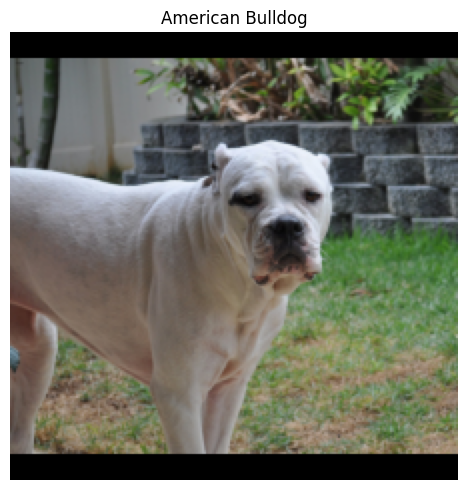

In [10]:
first_batch = iter(val_loader)
val_image, val_label = next(first_batch)


print(val_image.shape, val_label.shape)

image_for_plot = val_image[0].permute(1, 2, 0)
breed_name = class_names[val_label[0].item()]

plt.figure(figsize=(5, 5))

plt.imshow(image_for_plot)
plt.title(breed_name)

plt.axis("off")
plt.tight_layout()
plt.show()

### Сбор базовой CNN

Архитектура для входа `[32, 3, 224, 224]`:

| Блок | Операции | Форма выхода |
| :--- | :---- | :--- |
| 1 | `Conv2d(3, 16, 3, padding=1)` → ReLU → MaxPool2d(2) | `[32, 16, 112, 112]` |
| 2 | `Conv2d(16, 32, 3, padding=1)` → ReLU → MaxPool2d(2) | `[32, 32, 56, 56]` |
| 3 | `Conv2d(32, 64, 3, padding=1)` → ReLU → MaxPool2d(2) | `[32, 64, 28, 28]` |
| Усреднение | `AdaptiveAvgPool2d((4, 4))` | `[32, 64, 4, 4]` |
| Разворачивание | `Flatten()` | `[32, 1024]` |
| Классификатор | `Linear(1024, 37)` | `[32, 37]` |

In [11]:
from torch import nn

class PetCNN(nn.Module):
  def __init__(self, num_classes=37):
    super().__init__()

    self.features = nn.Sequential(
        nn.Conv2d(
            in_channels=3,
            out_channels=16,
            kernel_size=3,
            padding=1
        ),
        nn.ReLU(),
        nn.MaxPool2d(2),


        nn.Conv2d(
            in_channels=16,
            out_channels=32,
            kernel_size=3,
            padding=1
        ),
        nn.ReLU(),
        nn.MaxPool2d(2),


        nn.Conv2d(
            in_channels=32,
            out_channels=64,
            kernel_size=3,
            padding=1
        ),
        nn.ReLU(),
        nn.MaxPool2d(2),

        nn.AvgPool2d(
            kernel_size=7,
            stride=7
            ),
    )

    self.classifier = nn.Sequential(
        nn.Flatten(),
        nn.Linear(1024, num_classes),
    )


  def forward(self, x):
    x = self.features(x)
    logits  = self.classifier(x)
    return logits

In [12]:
torch.manual_seed(42)

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

model = PetCNN(num_classes=len(class_names)).to(device)

images, labels = next(iter(val_loader))

model.eval()

with torch.inference_mode():
  logits = model(images.to(device))

  loss = nn.CrossEntropyLoss()(
      logits,
      labels.to(device)
  )

print("Logits shape:", logits.shape)
print("Loss before training:", loss.item())

parameter_count = sum(p.numel() for p in model.parameters())
print("Parameters:", parameter_count)

Logits shape: torch.Size([32, 37])
Loss before training: 3.6089930534362793
Parameters: 61509


### Оценка качества для первого эксперимента

Выбранные метрики:

| **Метрика** | **Что измеряет** |
| :--- | :--- |
| Accuracy | Долю фотографий, для которых первый выборанный класс правильный |
| Macro-F1 | Среднее F1 по всем 37 породам с одинаковым весом каждой породы |
| Top-3 accuracy | Долю фотографий, где правильная порода попала в тройку выбранных |


## Функция валидации

In [13]:
import torch
from sklearn.metrics import f1_score


def evaluate_metrics(model, dataloader, loss_fn, device, num_classes):
    model.eval()

    total_loss = 0.0
    total_correct = 0
    total_top3_correct = 0
    total_objects = 0

    all_labels = []
    all_predictions = []

    with torch.inference_mode():
        for images, labels in dataloader:
            images = images.to(device)
            labels = labels.to(device)

            logits = model(images)
            loss = loss_fn(logits, labels)

            predictions = logits.argmax(dim=1)
            top3 = logits.topk(k=3, dim=1).indices

            batch_size = labels.size(0)

            total_loss += loss.item() * batch_size
            total_correct += (predictions == labels).sum().item()
            total_top3_correct += (
                (top3 == labels.unsqueeze(1))
                .any(dim=1)
                .sum()
                .item()
            )
            total_objects += batch_size

            all_labels.extend(labels.cpu().tolist())
            all_predictions.extend(predictions.cpu().tolist())

    macro_f1 = f1_score(
        all_labels,
        all_predictions,
        labels=list(range(num_classes)),
        average="macro",
        zero_division=0,
    )

    return {
        "loss": total_loss / total_objects,
        "accuracy": total_correct / total_objects,
        "macro_f1": macro_f1,
        "top3_accuracy": total_top3_correct / total_objects,
    }

In [14]:
metrics = evaluate_metrics(
    model,
    val_loader,
    nn.CrossEntropyLoss(),
    device,
    num_classes=len(class_names)
)

print(metrics)
print(f"Macro-F1: {metrics['macro_f1']:.4f}")

{'loss': 3.6113727300063423, 'accuracy': 0.029891304347826088, 'macro_f1': 0.004706667816622274, 'top3_accuracy': 0.08559782608695653}
Macro-F1: 0.0047


## Первый обучающий эксперимент

### Настройки модели:

| **Настройка** | **Значение** |
| :--- | :--- |
| Модель | Новый экземпляр `PetCNN` |
| Оптимизатор | Adam, `lr=0.001` |
| Функция потерь | `CrossEntropyLoss()` |
| Максимум эпох | 10 |
| Раняя остановка | 3 эпохи без улучшения |
| Критерий лучшей модели | **Максимальный validation macro-F1 |
| Файл | `checkpoints/pet_cnn_baseline.pth` |

### Обучение с сохранением и ранней остановкой

In [15]:
def train_one_epoch(
    model,
    dataloader,
    loss_fn,
    optimizer,
    device,
):

  model.train()

  total_loss = 0
  total_correct = 0
  total_objects = 0

  for images, labels in dataloader:
    images = images.to(device)
    labels = labels.to(device)

    optimizer.zero_grad()

    logits = model(images)
    loss = loss_fn(logits, labels)

    loss.backward()
    optimizer.step()

    batch_size = len(images)

    total_loss += loss.item() * batch_size
    total_correct += (
        logits.argmax(dim=1) == labels
    ).sum().item()

    total_objects += batch_size

  average_loss = total_loss / total_objects
  accuracy = total_correct / total_objects

  return average_loss, accuracy

In [16]:
from pathlib import Path

seed_everything(42)
train_loader.generator.manual_seed(42)

max_epochs = 20
patience = 3

best_epoch = None
epochs_without_improvement = 0

checkpoint_path = Path("checkpoints/best_cnn.pth")
checkpoint_path.parent.mkdir(parents=True, exist_ok=True)

model = PetCNN(num_classes=len(class_names)).to(device)
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)
loss_fn = nn.CrossEntropyLoss()

best_macro_f1 = -float("inf")


history = []

for epoch in range(1, max_epochs + 1):
  train_loss, train_accuracy = train_one_epoch(
      model,
      train_loader,
      loss_fn,
      optimizer,
      device
  )

  metrics = evaluate_metrics(
    model,
    val_loader,
    loss_fn,
    device,
    num_classes=len(class_names)
  )

  history.append({
      "epoch": epoch,
      "train_loss": train_loss,
      "train_accuracy": train_accuracy,
      "val_loss": metrics['loss'],
      "val_accuracy": metrics['accuracy'],
      "val_macro_f1":  metrics['macro_f1'],
      "val_top3_accuracy": metrics['top3_accuracy']
  })

  macro_f1 = metrics['macro_f1']

  if macro_f1 > best_macro_f1:
    best_macro_f1 = macro_f1
    best_epoch = epoch
    epochs_without_improvement = 0

    torch.save(
        {
        "model_state_dict": model.state_dict(),
        "epoch": epoch,
        "metrics": metrics,
        "class_names": class_names
        },
        checkpoint_path
    )
    status = "saved"

  else:
    epochs_without_improvement += 1
    status = (
        f"no improvment: "
        f"{epochs_without_improvement}/{patience}"
    )


  print(
      f"Epoch {epoch:2d}/{max_epochs} | "
      f"Train loss: {train_loss:.4f} | "
      f"Train accuracy: {train_accuracy:.2%} | "
      f"Val loss: {metrics['loss']:.4f} | "
      f"Val accuracy: {metrics['accuracy']:.2%} | "
      f"Val macro-F1: {metrics['macro_f1']:.4f} | "
      f"Val top3_accuracy: {metrics['top3_accuracy']:.4f} | "
      f"{status}"
  )

  if epochs_without_improvement >= patience:
    print("Early stopping")
    break


print(
    f"Best epoch: {best_epoch} | "
    f"Best val macro-F1: {best_macro_f1:.4f}"
)


Epoch  1/20 | Train loss: 3.6099 | Train accuracy: 2.79% | Val loss: 3.5831 | Val accuracy: 4.62% | Val macro-F1: 0.0235 | Val top3_accuracy: 0.1155 | saved
Epoch  2/20 | Train loss: 3.4742 | Train accuracy: 7.30% | Val loss: 3.3965 | Val accuracy: 6.93% | Val macro-F1: 0.0429 | Val top3_accuracy: 0.2160 | saved
Epoch  3/20 | Train loss: 3.2877 | Train accuracy: 11.68% | Val loss: 3.3388 | Val accuracy: 7.61% | Val macro-F1: 0.0569 | Val top3_accuracy: 0.2351 | saved
Epoch  4/20 | Train loss: 3.1700 | Train accuracy: 14.20% | Val loss: 3.2893 | Val accuracy: 10.60% | Val macro-F1: 0.0785 | Val top3_accuracy: 0.2663 | saved
Epoch  5/20 | Train loss: 3.1015 | Train accuracy: 14.98% | Val loss: 3.2759 | Val accuracy: 11.82% | Val macro-F1: 0.0948 | Val top3_accuracy: 0.2731 | saved
Epoch  6/20 | Train loss: 3.0226 | Train accuracy: 17.63% | Val loss: 3.2594 | Val accuracy: 11.01% | Val macro-F1: 0.0874 | Val top3_accuracy: 0.2812 | no improvment: 1/3
Epoch  7/20 | Train loss: 2.9497 | Tra

Best epoch: 15 | Best val macro-F1: 0.1620

### Проверка существующего результата

In [17]:
checkpoint = torch.load(
    checkpoint_path,
    map_location=device,
    weights_only=True,
)

baseline_model = PetCNN(
    num_classes=len(class_names)
).to(device)

baseline_model.load_state_dict(checkpoint["model_state_dict"])

baseline_metrics = evaluate_metrics(
    baseline_model,
    val_loader,
    loss_fn,
    device,
    num_classes=len(class_names),
)

print("Loaded epoch:", checkpoint["epoch"])
print(f"Val loss: {baseline_metrics['loss']:.4f}")
print(f"Val accuracy: {baseline_metrics['accuracy']:.2%}")
print(f"Val macro-F1: {baseline_metrics['macro_f1']:.4f}")
print(f"Val top-3 accuracy: {baseline_metrics['top3_accuracy']:.2%}")

Loaded epoch: 15
Val loss: 3.3073
Val accuracy: 17.80%
Val macro-F1: 0.1620
Val top-3 accuracy: 33.97%


## Transfer learning - перенос обучения

Наша модель `PetCNN` училась извлекать признаки с нуля на 2944 изображениях. Теперь возьмем **ResNet18 с весами, уже обученными на ImageNet**, и используем ее признаки для распознавания наших 37 пород


**Как будет устроена модель**

| **Часть** | **Что делает** | **Обучаем сейчас?** |
| :--- | :--- | :--- |
| Основная часть ResNet18 | Преобразует изображение в вектор из 512 признаков | Нет |
| Новый `Linear(512, 37)` | Преобразует признаки в 37 logits | Да |


Признаки основной части уже выучены на другом наборе изображений. Последний слой создадим со случайными весами - ему еще предстоит научиться связывать эти признаки с нашими породами

## Загрузка и подготовка модели

In [18]:
from torchvision.models import resnet18, ResNet18_Weights

seed_everything(42)

weights = ResNet18_Weights.IMAGENET1K_V1
resnet_model = resnet18(weights=weights)

print("Исходный классификатор:", resnet_model.fc)

# Замораживаем параметры существующих слоев
for parameter in resnet_model.parameters():
  parameter.requires_grad = False

# Заменяем классификатор новый обучаемым слоем
in_features = resnet_model.fc.in_features

resnet_model.fc = nn.Linear(
    in_features,
    len(class_names)
)

resnet_model = resnet_model.to(device)

print("Новый классификатор:", resnet_model.fc)

trainable_parameters = sum(
    parameter.numel()
    for parameter in resnet_model.parameters()
    if parameter.requires_grad
)

print("Обучаемых параметров:", trainable_parameters)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 176MB/s]


Исходный классификатор: Linear(in_features=512, out_features=1000, bias=True)
Новый классификатор: Linear(in_features=512, out_features=37, bias=True)
Обучаемых параметров: 18981


Здесь важен порядок: **сначала замораживаем существующие параметры, затем создаем новый слой**. У нового `Linear` параметры по умолчанию имеют `requires_grad=True`


**Для предобученных весов нужна соответствующая обработка изображений**


In [19]:
resnet_transform = weights.transforms()
print(resnet_transform)

ImageClassification(
    crop_size=[224]
    resize_size=[256]
    mean=[0.485, 0.456, 0.406]
    std=[0.229, 0.224, 0.225]
    interpolation=InterpolationMode.BILINEAR
)


Она уменьшает изображение с сохранением пропорций до короткой стороны 256, вырезает центральную область `224 × 224`, переводит значения в `[0, 1]` и нормализует каждый RGB-канал. Это обработка, рекомендованная для выбранных весов

Нормализация выглядит так:

$$ x_{normilized} = \frac{x - mean}{std} $$

После нее значения могут быть отрицательными и превышать единицу - это нормально

### Проверим одно изображение

Берем исходное PIL-изображение из `dataset`, где еще нет преобразований:

In [20]:
image, label = dataset[int(val_indices[0])]

image_tensor = resnet_transform(image)

# Добавляем размерность батча
inputs = image_tensor.unsqueeze(0).to(device)

resnet_model.eval()

with torch.inference_mode():
  logits = resnet_model(inputs)

print("Input shape:", inputs.shape)
print("Logits shape:", logits.shape)

Input shape: torch.Size([1, 3, 224, 224])
Logits shape: torch.Size([1, 37])


## Обучение последнего слоя ResNet18

Теперь обучим **наш последний слой `ResNet18` на наших 37 породах**. Новая тема здесь: *как сохранить основную часть модели полностью замороженной*

**Почему одного `requires_grad=False` недостаточно?**

В ResNet18 есть слои `BatchNorm2d`. Они нормализуют промежуточные признаки и хранят накопленные средние значения и дисперсии.

В режиме `train` эти статистики обновляются при прохождении батчей - даже если параметры слоя заморожены. В режиме `eval` используются сохраненные статистики.

Поэтому для нашего эксперимента:
```
model.eval()        # Сохраняем статистики основной части
model.fc.train()    # Последний слой переводим в режим обучения
```

**`eval()` не отключает градиенты**. Последний слой может обучаться через `loss.backward()` и `optimizer.step()`. А вот оборачивать **весь** обучающий проход в `torch.inference_model()` нельзя.

У самого `Linear()` поведение в `train()` и `eval()` одинаковое, но такой записью мы явно обозначаем, какую часть обучаем.


### Подготовим загрузчики

Используем уже созданное разбиение и обработку `weights.transforms()`. Она включает resize, центральную обрезку и нормализацию для предобученных весов

In [21]:
weights = ResNet18_Weights.IMAGENET1K_V1
resnet_transform = weights.transforms()

resnet_train_source = OxfordIIITPet(
    root='data',
    split='trainval',
    target_types='category',
    transform=resnet_transform,
    download=False,
)

resnet_val_source = OxfordIIITPet(
    root='data',
    split='trainval',
    target_types='category',
    transform=resnet_transform,
    download=False,
)


resnet_train_dataset = Subset(
    resnet_train_source, train_indices.tolist()
)

resnet_val_dataset = Subset(
    resnet_val_source, val_indices.tolist()
)


resnet_train_loader = DataLoader(
    resnet_train_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=0,
    generator=torch.Generator().manual_seed(42),
)

resnet_val_loader = DataLoader(
    resnet_val_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=0
)

assert resnet_train_source.classes == class_names

## Функция обучения последнего слоя

Это уже знакомый цикл. Основное изменение - первые две строки внутри функции

In [22]:
def train_head_one_epoch(
    model, dataloader, loss_fn, optimizer, device
):
  model.eval()
  model.fc.train()

  total_loss = 0
  total_correct = 0
  total_objects = 0

  for images, labels in dataloader:
    images = images.to(device)
    labels = labels.to(device)

    optimizer.zero_grad()

    logits = model(images)
    loss = loss_fn(logits, labels)

    loss.backward()
    optimizer.step()

    batch_size = labels.size(0)
    total_loss += loss.item() * batch_size
    total_correct += (
        logits.argmax(dim=1) == labels
    ).sum().item()
    total_objects += batch_size

  return (
      total_loss / total_objects,
      total_correct / total_objects
  )

Здесь изображения проходят через всю сеть, но градиенты вычисляются только для нового `fc`

### Первый эксперимент - пять эпох

In [ ]:
seed_everything(42)
resnet_train_loader.generator.manual_seed(42)

resnet_model = resnet18(weights=weights)

for parameter in resnet_model.parameters():
  parameter.requires_grad = False

resnet_model.fc = nn.Linear(
    resnet_model.fc.in_features,
    len(class_names),
)

resnet_model = resnet_model.to(device)

# Передаем оптимизатору только параметры последнего слоя
resnet_optimizer = torch.optim.Adam(
    resnet_model.fc.parameters(),
    lr=0.001,
)
loss_fn = nn.CrossEntropyLoss()

resnet_checkpoint_path = Path(
    "checkpoints/resnet18_head.pth"
)

resnet_checkpoint_path.parent.mkdir(
    parents=True, exist_ok=True
)

resnet_history = []

best_macro_f1 = -float("inf")
best_epoch = None
epochs_without_improvement = 0

max_epochs = 15
patience = 3
min_delta = 1e-4

for epoch in range(1, max_epochs+1):
  train_loss, train_accuracy = train_head_one_epoch(
      resnet_model,
      resnet_train_loader,
      loss_fn,
      resnet_optimizer,
      device,
  )

  metrics = evaluate_metrics(
      resnet_model,
      resnet_val_loader,
      loss_fn,
      device,
      num_classes=len(class_names),
  )

  resnet_history.append({
      'epoch': epoch,
      'train_loss': train_loss,
      'train_accuracy': train_accuracy,
      'val_loss': metrics["loss"],
      'val_accuracy': metrics['accuracy'],
      'val_macro_f1': metrics['macro_f1'],
      'val_top3_accuracy': metrics['top3_accuracy'],
  })

  status = ""

  if metrics['macro_f1'] > best_macro_f1 + min_delta:
    best_macro_f1 = metrics['macro_f1']
    best_epoch = epoch
    epochs_without_improvement = 0

    torch.save({
        'model_state_dict': resnet_model.state_dict(),
        'epoch': epoch,
        'metrics': metrics,
        'class_names': class_names,
        'weights': 'IMAGENET1K_V1',
    }, resnet_checkpoint_path)

    status = 'saved'

  else:
    epochs_without_improvement += 1
    status = (
        f"No improvement: "
        f"{epochs_without_improvement}/{patience}"
    )

  print(
      f"Epoch {epoch}/{max_epochs} | "
      f"Train loss: {train_loss:.4f} | "
      f"Train accuracy: {train_accuracy:.2%} | "
      f"Val loss: {metrics['loss']:.4f} | "
      f"Val accuracy: {metrics['accuracy']:.2%} | "
      f"Val macro-F1: {metrics['macro_f1']:.4f} | "
      f"{status}"
  )

  if epochs_without_improvement >= patience:
    print("Early stopping")
    break

Epoch 1/15 | Train loss: 1.8055 | Train accuracy: 60.70% | Val loss: 0.8145 | Val accuracy: 86.41% | Val macro-F1: 0.8609 | saved
Epoch 2/15 | Train loss: 0.5829 | Train accuracy: 89.61% | Val loss: 0.5030 | Val accuracy: 89.95% | Val macro-F1: 0.8996 | saved
Epoch 3/15 | Train loss: 0.3822 | Train accuracy: 92.70% | Val loss: 0.4020 | Val accuracy: 90.08% | Val macro-F1: 0.9011 | saved
Epoch 4/15 | Train loss: 0.2926 | Train accuracy: 94.29% | Val loss: 0.3547 | Val accuracy: 90.08% | Val macro-F1: 0.9008 | No improvement: 1/3
Epoch 5/15 | Train loss: 0.2381 | Train accuracy: 95.75% | Val loss: 0.3170 | Val accuracy: 91.58% | Val macro-F1: 0.9163 | saved
Epoch 6/15 | Train loss: 0.1986 | Train accuracy: 96.33% | Val loss: 0.3157 | Val accuracy: 91.17% | Val macro-F1: 0.9117 | No improvement: 1/3
Epoch 7/15 | Train loss: 0.1695 | Train accuracy: 97.11% | Val loss: 0.2867 | Val accuracy: 91.71% | Val macro-F1: 0.9173 | saved
Epoch 8/15 | Train loss: 0.1472 | Train accuracy: 97.62% | Val

### Вернем лучшие веса

In [ ]:
checkpoint = torch.load(
    resnet_checkpoint_path,
    map_location=device,
    weights_only=True
)

resnet_model.load_state_dict(
    checkpoint['model_state_dict']
)

resnet_metrics = evaluate_metrics(
    resnet_model,
    resnet_val_loader,
    loss_fn,
    device,
    num_classes=len(class_names)
)

print("Loaded epoch:", checkpoint['epoch'])

for name, value in resnet_metrics.items():
  print(f"{name}: {value:.4f}")

## `fine-tuning` последнего блока `layer4`

Сейчас ResNet работает как фиксированный извлекатель признаков, теперь позволим ее наиболее высокоуровневым признакам немного адаптироваться к породам животоных. Это второй стандартный сценарий transfer learning после обучения классификатора. [PyTorch Transfer Learning Tutorial](https://docs.pytorch.org/tutorials/beginner/transfer_learning_tutorial.html)

При этом:
  * `layer1-layer3` остаются замороженными;
  * `layer4` и `fc` обучаются;
  * для `layer4` используем очень маленький learning rate;
  * обработку изображений пока не меняем, чтобы проверить только эффект разморозки


### **1 Новая функция обучения**

In [ ]:
def train_layer4_one_epoch(
    model, dataloader, loss_fn, optimizer, device
):
  # Замороженная часть остается в eval
  model.eval()

  # Дообучаемые части переводим в train
  model.fc.train()
  model.layer4.train()

  total_loss = 0.0
  total_correct = 0
  total_objects = 0

  for images, labels in dataloader:
    images = images.to(device)
    labels = labels.to(device)

    optimizer.zero_grad()

    logits = model(images)
    loss = loss_fn(logits, labels)

    loss.backward()
    optimizer.step()

    batch_size = labels.size(0)

    total_loss += loss.item() * batch_size
    total_correct += (
        logits.argmax(dim=1) == labels
    ).sum().item()
    total_objects += batch_size

  return (
      total_loss / total_objects,
      total_correct / total_objects
  )


Теперь `BatchNorm` внутри `layer4` тоже работает в режиме обучения, а статистики замороженных блоков не обновляются

### **2 Восстанавливаем лучшую head-only модель**

In [ ]:
seed_everything(42)
resnet_train_loader.generator.manual_seed(42)

head_checkpoint = torch.load(
    resnet_checkpoint_path,
    map_location="cpu",
    weights_only=True
)

fine_tune_model = resnet18(weights=None)

fine_tune_model.fc = nn.Linear(
    fine_tune_model.fc.in_features,
    len(class_names),
)

fine_tune_model.load_state_dict(
    head_checkpoint["model_state_dict"]
)

# Сначала замораживаем всю модель
for parameter in fine_tune_model.parameters():
  parameter.requires_grad = False

# Размораживаем layer4
for parameter in fine_tune_model.layer4.parameters():
  parameter.requires_grad = True

# И классификатор
for parameter in fine_tune_model.fc.parameters():
  parameter.requires_grad = True

fine_tune_model = fine_tune_model.to(device)

Мы используем `weights=None`, потому что веса ImageNet сейчас не нужны: сразу после создания архитектуры загружается наш checkpoint 11-й эпохи

Проверим параметры:

In [ ]:
trainable_names = [
    name
    for name, parameter in fine_tune_model.named_parameters()
    if parameter.requires_grad
]

assert all(
    name.startswith(("layer4.", "fc."))
    for name in trainable_names
)

trainable_parameters = sum(
    parameter.numel()
    for parameter in fine_tune_model.parameters()
    if parameter.requires_grad
)

print("Trainable parameters:", trainable_parameters)
print("First trainable parameter:", trainable_names[0])
print("Last trainable parameter:", trainable_names[-1])

### 3 Разные learning rate

In [ ]:
fine_tune_optimizer = torch.optim.Adam(
    [
        {
            "params": fine_tune_model.layer4.parameters(),
            "lr": 1e-5,
        },
        {
            "params": fine_tune_model.fc.parameters(),
            "lr": 1e-4,
        }
    ]
)

`layer4` уже содержит полезные предобученные признаки, поэтому изменяем ее осторожнее. `fc` получает learning rate в десять раз больше. PyTorch позволяет задавать отдельные настройки для групп параметров через optimizer parameters groups

### 4 Fine-tuning


In [ ]:
fine_tune_checkpoint_path = Path(
    "checkpoints/resnet18_layer4.pth"
)

fine_tune_history = []

# Начинаем сравнение с результатом head-only модели
best_macro_f1 = head_checkpoint["metrics"]["macro_f1"]
best_epoch = 0
epochs_without_improvement = 0

max_epochs = 10
patience = 3
min_delta = 1e-4

for epoch in range(1, max_epochs+1):
  train_loss, train_accuracy = train_layer4_one_epoch(
      fine_tune_model,
      resnet_train_loader,
      loss_fn,
      fine_tune_optimizer,
      device,
  )

  metrics = evaluate_metrics(
      fine_tune_model,
      resnet_val_loader,
      loss_fn,
      device,
      num_classes=len(class_names),
  )

  fine_tune_history.append({
      "epoch": epoch,
      "train_loss": train_loss,
      "train_accuracy": train_accuracy,
      "val_loss": metrics["loss"],
      "val_accuracy": metrics["accuracy"],
      "val_macro_f1": metrics["macro_f1"],
      "val_top3_accuracy": metrics["top3_accuracy"],
  })

  if metrics['macro_f1'] > best_macro_f1 + min_delta:
    best_macro_f1 = metrics['macro_f1']
    best_epoch = epoch
    epochs_without_improvement = 0
    status = 'saved'

    torch.save(
        {
            "model_state_dict": fine_tune_model.state_dict(),
            "optimizer_state_dict": fine_tune_optimizer.state_dict(),
            "epoch": epoch,
            "metrics": metrics,
            "class_names": class_names,
            "weights": "IMAGENET1K_V1",
            "stage": "layer4_fine_tuning",
        },
        fine_tune_checkpoint_path
    )

  else:
      epochs_without_improvement += 1
      status = (
          f"No improvement: "
          f"{epochs_without_improvement}/{patience}"
      )

  print(
      f"Epoch {epoch}/{max_epochs} | "
      f"Train loss: {train_loss:.4f} | "
      f"Train accuracy: {train_accuracy:.2%} | "
      f"Val loss: {metrics['loss']:.4f} | "
      f"Val accuracy: {metrics['accuracy']:.2%} | "
      f"Val macro-F1: {metrics['macro_f1']:.4f} | "
      f"{status}"
  )

  if epochs_without_improvement >= patience:
      print("Early stopping")
      break


Здесь `best_epoch=0` означает исходную head_only model до fine-tuning. Если ни одна эпоха не превысит `0.9273`, новый checkpoint не появится - это честный вывод, что разморозка пока не помогла


Следующий логичный эксперимент - добавить мягкую аугментацию только в обучающую выборку.

Для обучения используем случайную аугментацию, для validation — прежнее детерминированное преобразование:

In [ ]:
resnet_train_transform = transforms.Compose([
    transforms.RandomResizedCrop(
        224,
        scale=(0.8, 1.0)
    ),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    ),
])

# Validation-преобразования оставим прежними и детерменированными
resnet_val_transform = weights.transforms()

In [ ]:
aug_train_source = OxfordIIITPet(
    root="data",
    split="trainval",
    target_types="category",
    transform=resnet_train_transform,
    download=False,
)

aug_val_source = OxfordIIITPet(
    root="data",
    split="trainval",
    target_types="category",
    transform=resnet_val_transform,
    download=False,
)


aug_train_dataset = Subset(
    aug_train_source,
    train_indices.tolist()
)

aug_val_dataset = Subset(
    aug_val_source,
    val_indices.tolist()
)


aug_train_loader = DataLoader(
    aug_train_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=0,
    generator=torch.Generator().manual_seed(42)
)

aug_val_loader = DataLoader(
    aug_val_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=0
)